<a href="https://colab.research.google.com/github/AdityaVarma-7558/AdityaVarma-25BAI0189/blob/main/EDA%20Exp%20-%209%7C22.09.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/airline-passengers.csv")
zero_mean_series = np.random.normal(loc=0.0, scale=1.0, size=50)
df_power = pd.read_csv('/content/airline-passengers.csv')

In [3]:
print(f"Dataset Shape: {df.shape}\n")

Dataset Shape: (144, 2)



In [4]:
print("First 3 entries:")
print(df.head(3), "\n")

First 3 entries:
     month  total_passengers
0  1949-01               112
1  1949-02               118
2  1949-03               132 



In [5]:
if 'month' in df.columns:
    df.rename(columns={'month': 'Date', 'total_passengers': 'Passengers'}, inplace=True)
elif 'Month' in df.columns:
    df.rename(columns={'Month': 'Date', 'Passengers': 'Passengers'}, inplace=True)

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

In [7]:
print("Random Sampling of 5 rows:")
print(df.sample(5, random_state=0), "\n")

Random Sampling of 5 rows:
            Passengers
Date                  
1949-08-01         148
1956-06-01         374
1957-02-01         301
1951-03-01         178
1958-03-01         362 



In [8]:
print("Time-based indexing output for January 1950:")
print(df.loc['1950-01'], "\n")

Time-based indexing output for January 1950:
            Passengers
Date                  
1950-01-01         115 



In [9]:
sns.set(rc={'figure.figsize':(11, 4)})
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['figure.dpi'] = 150

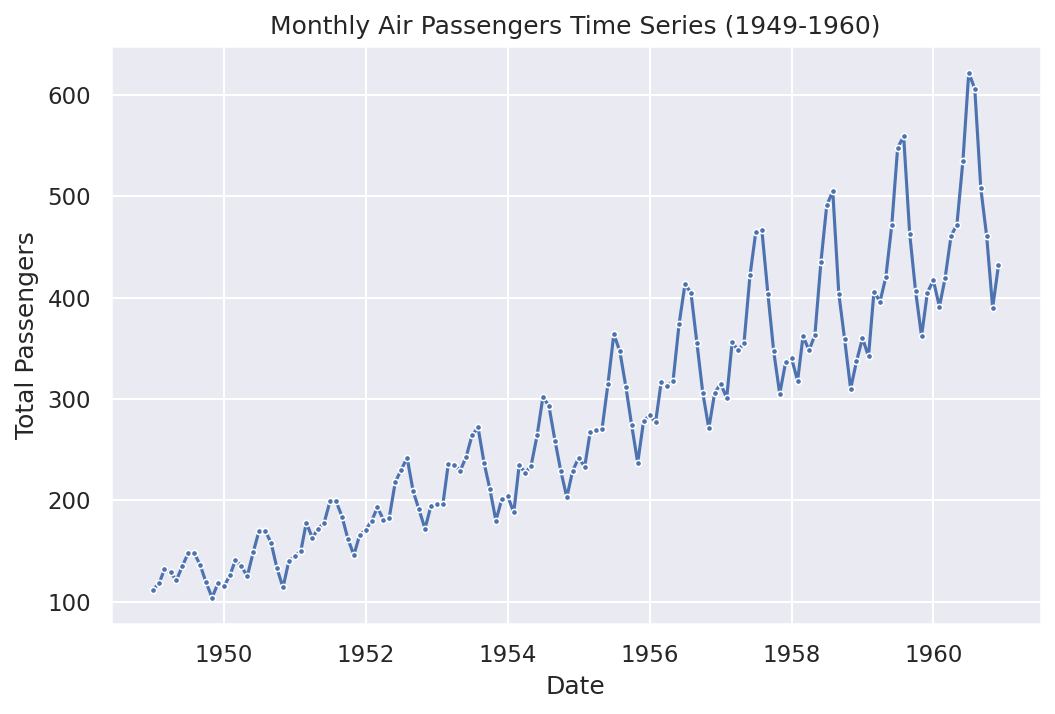

In [10]:
plt.figure()
sns.lineplot(data=df, x=df.index, y='Passengers', linewidth=1.5, marker='.')
plt.title('Monthly Air Passengers Time Series (1949-1960)')
plt.xlabel('Date')
plt.ylabel('Total Passengers')
plt.grid(True)
plt.show()

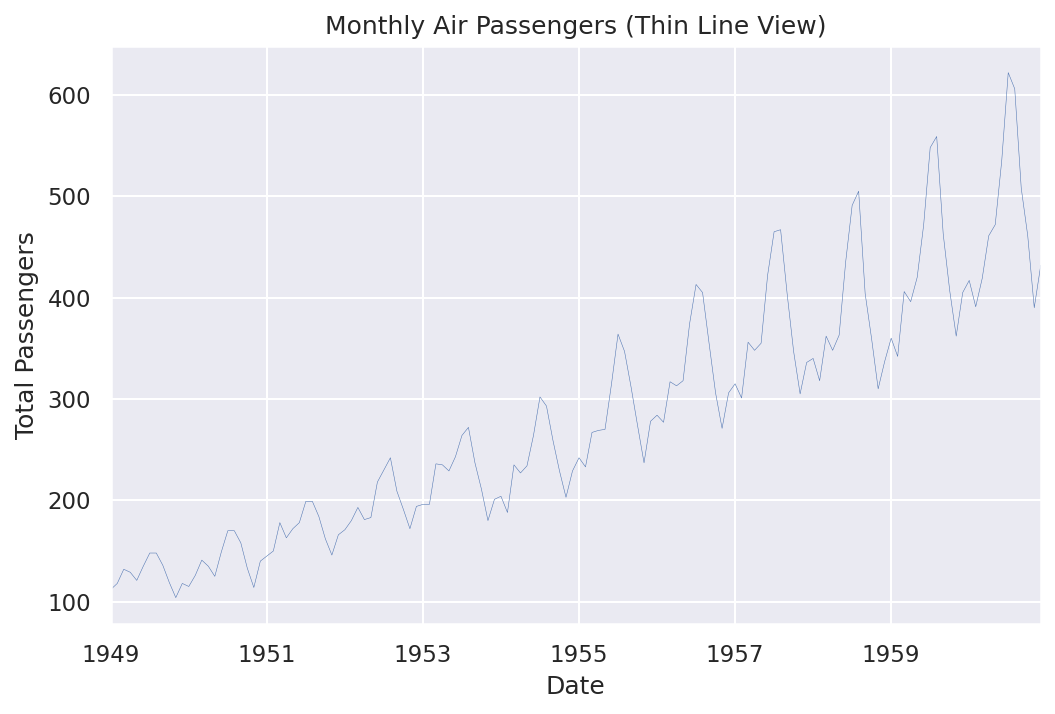

In [11]:
df['Passengers'].plot(linewidth=0.25)
plt.title('Monthly Air Passengers (Thin Line View)')
plt.ylabel('Total Passengers')
plt.show()

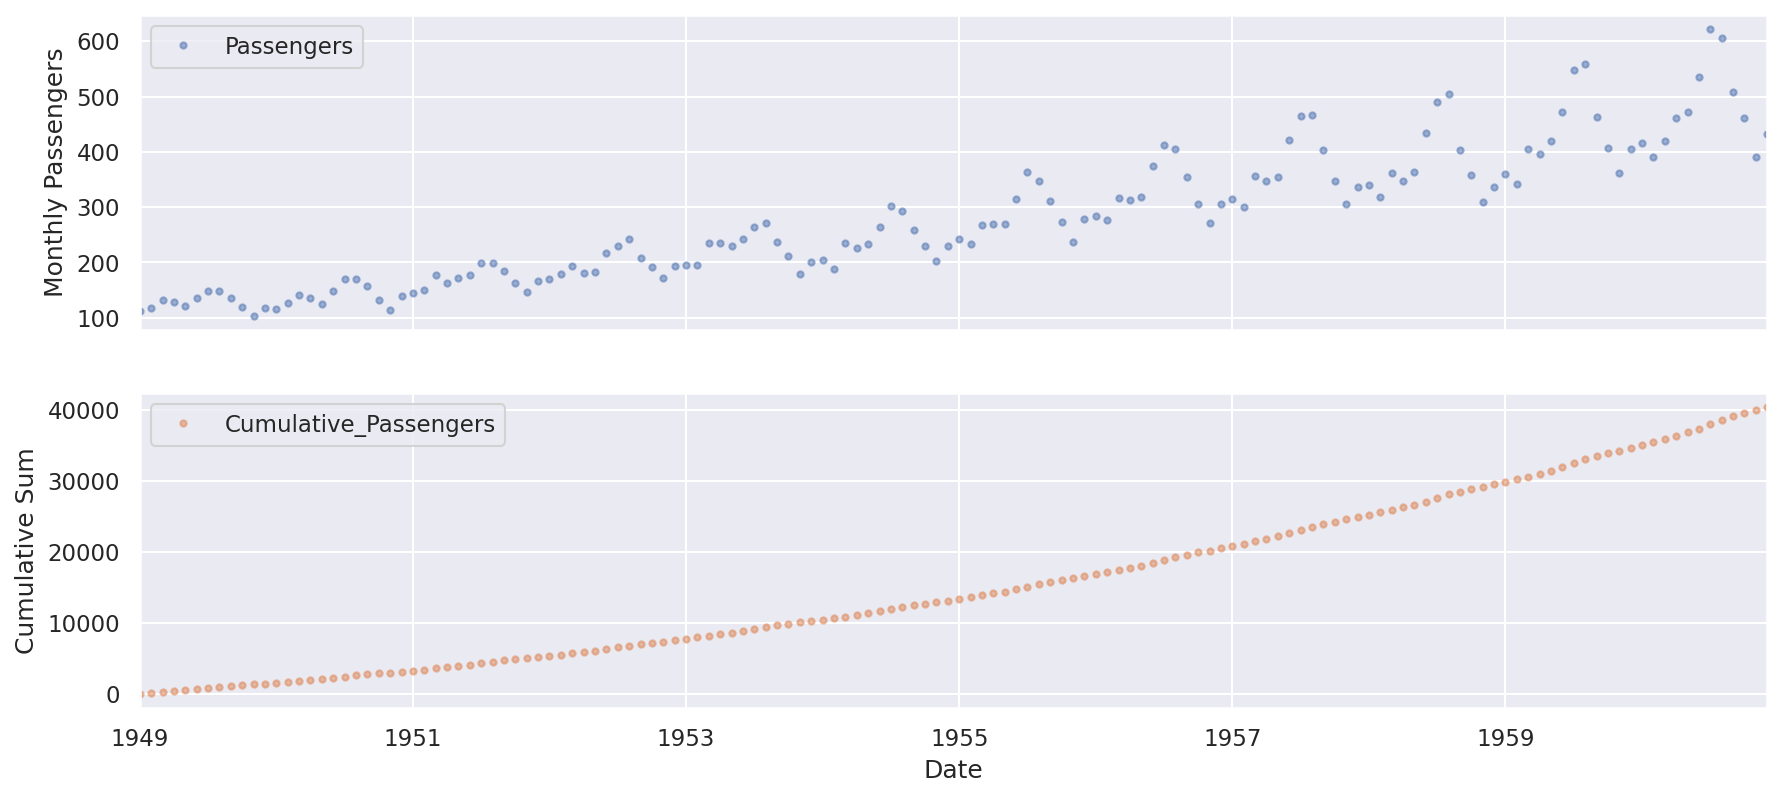

In [15]:
cols_to_plot = ['Passengers', 'Cumulative_Passengers']
axes = df[cols_to_plot].plot(marker='.', alpha=0.5,
                             linestyle='None', figsize=(14, 6), subplots=True)
axes[0].set_ylabel('Monthly Passengers')
axes[1].set_ylabel('Cumulative Sum')
plt.show()

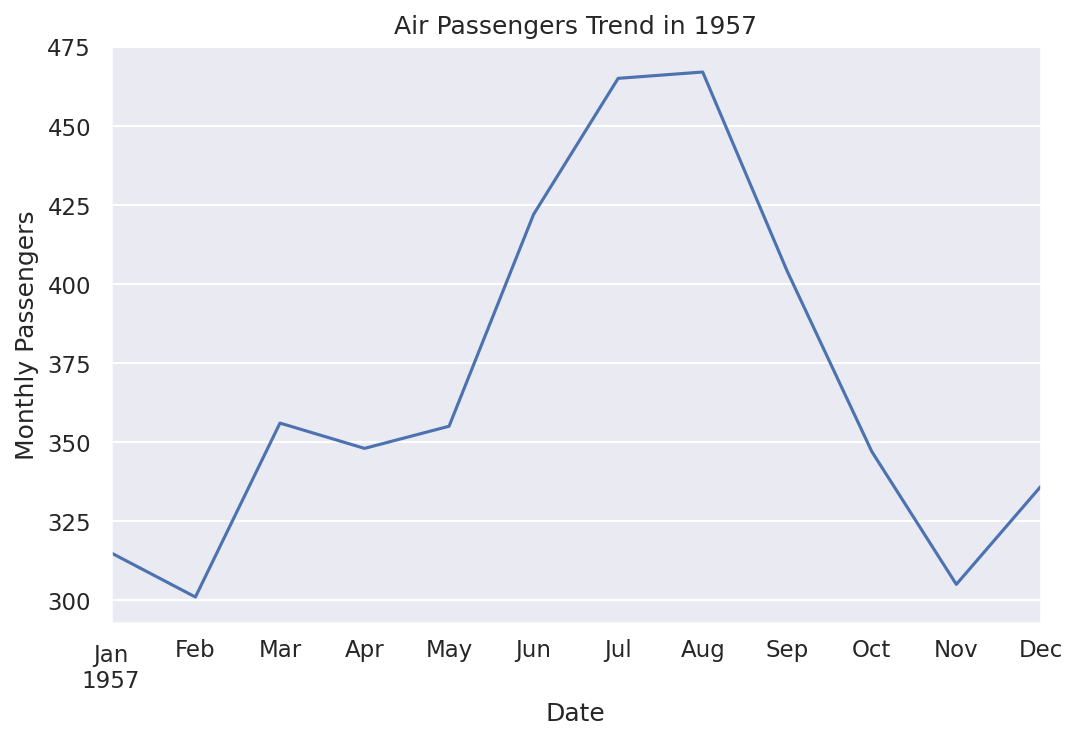

In [13]:
ax = df.loc['1957', 'Passengers'].plot()
ax.set_ylabel('Monthly Passengers');
ax.set_title('Air Passengers Trend in 1957')
plt.show()

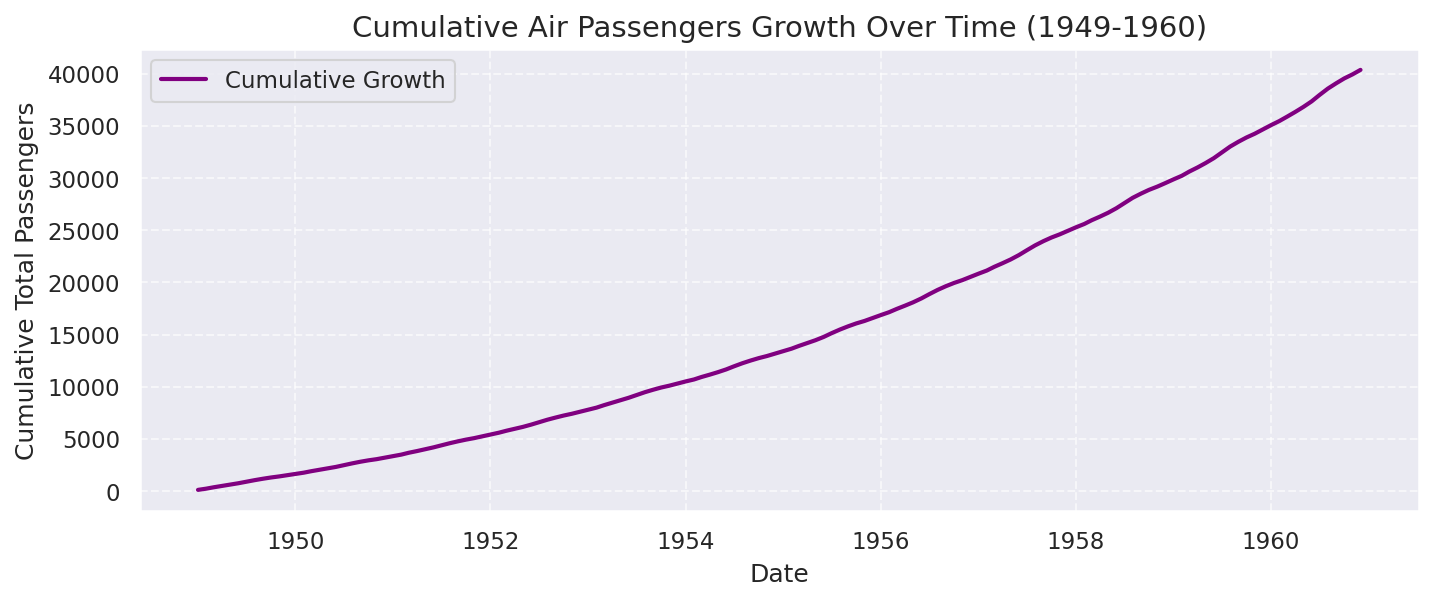

In [14]:
df['Cumulative_Passengers'] = np.cumsum(df['Passengers'])

plt.figure(figsize=(11, 4))
plt.plot(df.index, df['Cumulative_Passengers'], color='purple', linewidth=2, label='Cumulative Growth')

plt.title('Cumulative Air Passengers Growth Over Time (1949-1960)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Total Passengers', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Yearly Mean Resampled Data:
            Passengers  Cumulative_Passengers
Date                                         
1949-12-31  126.666667             824.250000
1950-12-31  139.666667            2411.916667
1951-12-31  170.166667            4290.000000
1952-12-31  197.000000            6497.833333
1953-12-31  225.000000            9068.833333 



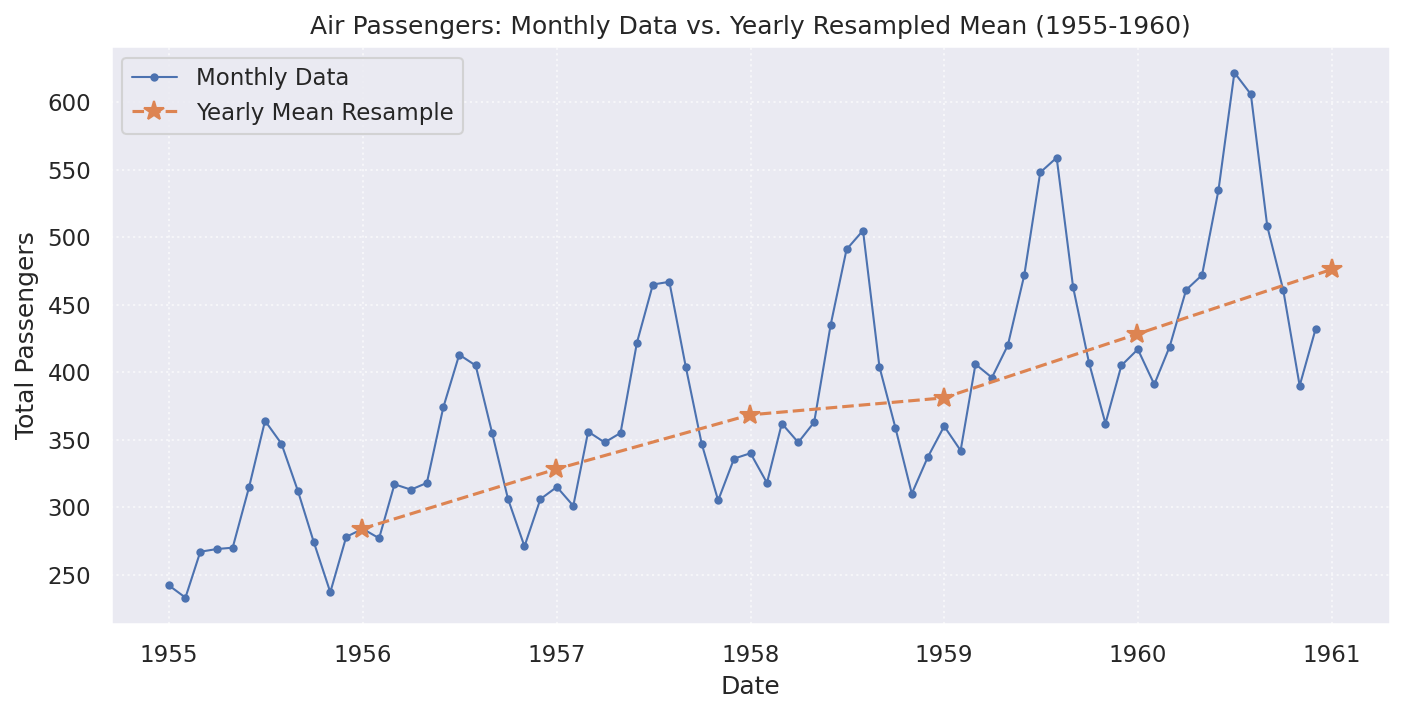

In [16]:
columns = ['Passengers', 'Cumulative_Passengers']

passengers_yearly_mean = df[columns].resample('YE').mean()
print("Yearly Mean Resampled Data:")
print(passengers_yearly_mean.head(), "\n")

start, end = '1955-01', '1960-12'
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df.loc[start:end, 'Passengers'], marker='.', linestyle='-', linewidth=1.0, label='Monthly Data')

ax.plot(passengers_yearly_mean.loc[start:end, 'Passengers'], marker='*', markersize=10, linestyle='--', linewidth=1.5, label='Yearly Mean Resample')
ax.set_title('Air Passengers: Monthly Data vs. Yearly Resampled Mean (1955-1960)')
ax.set_ylabel('Total Passengers')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()